In [2]:
import numpy as np
import os 
import matplotlib.pyplot as plt

In [2]:

notebook_dir = os.getcwd()

SEED_IMAGE_PATH = os.path.join(
    notebook_dir,
    "..", "data", "seed", "MAX_2025.08.23-Glastini_Gcamp6s_10min_xyt.png"
)
SEED_MASK_PATH = os.path.join(
    notebook_dir,
    "..", "data", "seed", "MAX_2025.08.23-Glastini_Gcamp6s_10min_xyt_seg.npy"
)

SEED_IMAGE_PATH2 = os.path.join(
    notebook_dir,
    "..", "data", "seed2", "MAX_2025.08.23-Glastini_Gcamp6s_10min_xyt.png"
)
SEED_MASK_PATH2 = os.path.join(
    notebook_dir,
    "..", "data", "seed2", "MAX_2025.08.23-Glastini_Gcamp6s_10min_xyt_seg.npy"
)

2025-09-20 11:17:16 | cellpose.models | WARNING | pretrained_model path does not exist, using default model
2025-09-20 11:17:16 | cellpose.core | INFO | >>>> using CPU
2025-09-20 11:17:16 | cellpose.core | INFO | >>>> using CPU
2025-09-20 11:17:16 | cellpose.models | INFO | >>>> loading model C:\Users\javid.rezai\.cellpose\models\cyto3
2025-09-20 11:17:17 | cellpose.models | INFO | >>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)


Lx: 1024, Ly: 1024, nframes: 60
(1024, 1024)


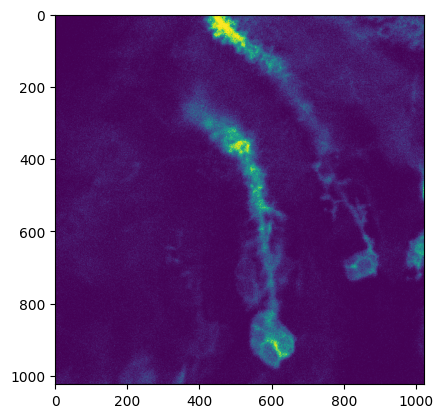

In [5]:
from suite2p.io import BinaryFile

ops_path = r"C:\Users\javid.rezai\YaksiLab\duygu\data\glast-gfp_OT_baseline_C=2_xyt\suite2p\plane0\ops.npy"
data_bin_path = r"C:\Users\javid.rezai\YaksiLab\duygu\data\glast-gfp_OT_baseline_C=2_xyt\suite2p\plane0\data.bin"

from astroglial_morphology.segmentation import Segmentation

seg = Segmentation()



ops = np.load(ops_path, allow_pickle=True).item()
Lx = ops['Lx']
Ly = ops['Ly']
nframes = ops['nframes']
print(f"Lx: {Lx}, Ly: {Ly}, nframes: {nframes}")

data = BinaryFile(Ly=Ly, Lx=Lx,filename=data_bin_path)
data.data[0].shape  # (n_frames, Ly, Lx)

mask = seg.segment_img(data.data[0],diameter=290)
print(mask.shape)
mask2 = seg.segment_img(data.data[1])
# plot the mask

plt.imshow(data.data[0])

plt.show()

In [22]:
fram_jump = 20

segment_generator = seg.segment_binaryfile(ops_path, data_bin_path, frame_jump=fram_jump,resample=True)

frame_masks = []

for i, mask in segment_generator:
    frame_masks.append(mask)
    unique_masks = np.unique(mask)
    unique_masks = unique_masks[unique_masks != 0]
    print(f"Frame {i} has {len(unique_masks)} unique masks")
    for mask_id in unique_masks:
        mask_pixels = np.sum(mask == mask_id)
        print(f"  Mask {mask_id}: {mask_pixels} pixels")

frame_masks = np.array(frame_masks)


2025-09-17 23:42:47 | astroglial_morphology.segmentation | INFO | Starting segmentation of 60 frames with frame jump 20
2025-09-17 23:42:47 | astroglial_morphology.segmentation | INFO | Segmenting frame 1/60


2025-09-17 23:42:55 | astroglial_morphology.segmentation | INFO | Segmenting frame 21/60


Frame 0 has 2 unique masks
  Mask 1: 48470 pixels
  Mask 2: 77871 pixels


2025-09-17 23:43:04 | astroglial_morphology.segmentation | INFO | Segmenting frame 41/60


Frame 20 has 2 unique masks
  Mask 1: 48879 pixels
  Mask 2: 76499 pixels


2025-09-17 23:43:12 | astroglial_morphology.segmentation | INFO | Segmentation completed


Frame 40 has 2 unique masks
  Mask 1: 49249 pixels
  Mask 2: 74045 pixels


(1024, 1024)
1


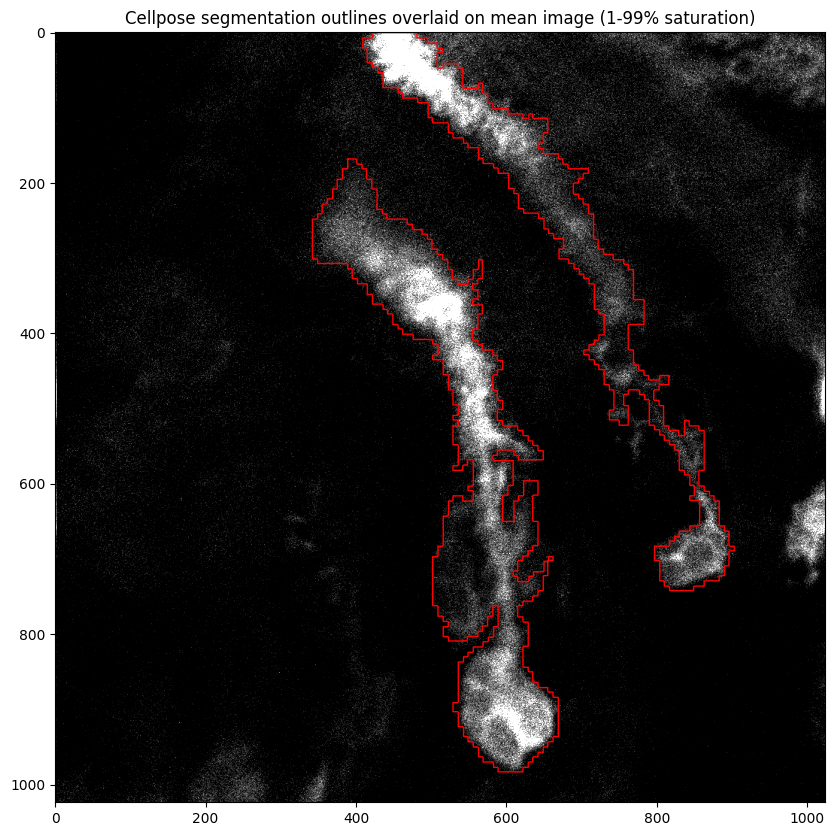

In [ ]:
# Start of Selection
# Create figure with image and mask outline


fig, ax = plt.subplots(figsize=(10, 10))

# Saturate the image slightly for better visualization
vmin, vmax = np.percentile(data.data[0], (60, 99))
ax.imshow(data.data[0], cmap='gray', vmin=vmin, vmax=vmax)

# Plot mask outlines
from cellpose import utils
outlines = utils.outlines_list(masks)
for outline in outlines:
    ax.plot(outline[:, 0], outline[:, 1], color='red', linewidth=1)

ax.set_title('Cellpose segmentation outlines overlaid on mean image (1-99% saturation)')
plt.show()
